# Data Wrangling Tasks: AI Survey

In this notebook, you will perform some data processing on the responses to the AI Survey.

The AI Survey responses are available in the shared folder on our Jupyter Hub:

`/home/shared/AI_Attitudes.csv`

Run the code below to load the CSV file into a pandas dataframe. Then perform the following tasks to clean and recode the data. In particular, Task 4 will allow us to compare our responses to the [Pew Research foundation Survey](https://www.pewresearch.org/science/2025/09/17/how-americans-view-ai-and-its-impact-on-people-and-society/).

## Your Tasks
1. Load data into a pandas dataframe.
2. Rename columns - they are way too long!
3. Drop columns that are not relevant to our analysis.
4. Create a column called 'Net Excited-Concerned'. This column will contain an integer value that represents the difference between how excited and concerned a respondent is.
5. Create a new column called 'Excited vs Concerned'. This column will contain the following categorical data, based on respondents'  'Net Excited-Concerned' score:
   - More excited than concerned
   - Equally excited and concerned
   - More Concerned that excited
6. Use this to compare our survey results to the Pew Research survey.
7. Create a column that gives a count of how many tools people report using, based on their answer to the 'Which of the following AI tools have you used?' question. Use this to create a bar chart showing the distribution.
8. Finally, think about other questions you might want to ask about the data and any recoding or data processing that might be necessary to answer these questions.

In [1]:
from datetime import date
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

file = "/home/shared/AI_Attitudes.csv"
df = pd.read_csv(file)
df

,ID,Start time,Completion time,Email,Name,Last modified time,"Before answering a few questions about AI, please tell us a bit about yourself. \n\nFirstly, what is your age?",What is your gender?,"On a scale of 1-10 where 1 means not at all excited and 10 means very excited, how excited are you about the increased use of AI in daily life?","What things in particular make you excited about the increased use of AI in daily life? If you are not very excited about AI, or you are not sure, you can skip this question.","On a scale of 1-10 where 1 means not at all concerned and 10 means very concerned, how concerned are you about the increased use of AI in daily life?","What things in particular make you concerned about the increased use of AI in daily life? If you are not very concerned about AI, or are not sure, you can skip this question.",How often do you use AI in your daily life? Select the best answer.,"In a few words, describe the main ways in which you use AI and what you use it for. For example, customize my resume, draft code, answer search questions, help with homework, etc.","Which of the following AI tools have you used? Select all that apply. If you are not sure or have not used any of these, you can skip this question. If there is a tool you have used that is not li...","If you would like a copy of the report when it is completed, please provide your email here. This is optional and your email will only be used to share this report. It will not be shared with thir..."
0,11,2/20/26 9:26:30,2/20/26 9:28:20,anonymous,NaN,NaN,45-54,Male,4,Making coding easier,9,Concerned about impact on employment prospects...,Several times a day,"search, finding out how to code things.",Microsoft Copilot;Chat GPT;Google Gemini;,NaN
1,12,2/20/26 9:52:31,2/20/26 10:03:38,anonymous,NaN,NaN,45-54,Female,8,It simplifies otherwise manual tasks and it’s ...,8,It has become a crutch for me - I have come to...,Several times a day,See above.,Chat GPT;Claude (Anthropic);Microsoft Copilot;,NaN
2,13,2/20/26 11:52:56,2/20/26 11:54:14,anonymous,NaN,NaN,55 or over,Female,7,NaN,4,NaN,A few times a week,Answer search questions,Chat GPT;Microsoft Copilot;,NaN
3,14,2/20/26 11:55:10,2/20/26 12:06:45,anonymous,NaN,NaN,25-34,Male,10,The possibilities that become more probable wh...,10,Dependency on AI to solve simple problems we s...,Several times a day,"Resume, Explain Complex Code, Math Tutor, draf...",Notebook LM;Google Gemini;Perplexity AI;Claude...,daytwans@icloud.com
4,15,2/20/26 13:38:13,2/20/26 13:39:51,anonymous,NaN,NaN,45-54,Female,2,NaN,8,"Outsourced thinking, loss of human creativity ...",A few times a week,Analyse data.,Notebook LM;Chat GPT;Microsoft Copilot;,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,119,3/4/26 10:13:23,3/4/26 10:15:23,anonymous,NaN,NaN,25-34,Female,8,Being able to use AI as a tool to further my k...,4,The movie IRobot,Several times a day,"Spell check homework, answer questions",Google Gemini;Grammarly;Claude (Anthropic);Cha...,NaN
109,120,3/4/26 11:00:36,3/4/26 11:18:28,anonymous,NaN,NaN,25-34,Female,5,I feel neutral about the use of AI in people’s...,6,"Up until about 3 weeks ago, I did not think of...",A few times a week,I actually use it mainly for health reasons. I...,Chat GPT;Google Gemini;,karxico10@gmail.com
110,121,3/4/26 11:19:28,3/4/26 11:23:29,anonymous,NaN,NaN,45-54,Female,8,I can do work faster since i write many emails.,9,Water usage and young people using there brain...,About once a day,Help with items at work!,Chat GPT;Microsoft Copilot;Google Gemini;,Elizabeth_munoz1512@yahoo.com
111,122,3/4/26 11:24:48,3/4/26 11:29:46,anonymous,NaN,NaN,35- 44,Female,8,I like to use AI for career development as wel...,6,I do worry about how it affects the environment.,Several times a day,"I use it for resume, cover letters, career pla...",Chat GPT;Perplexity AI;Google Gemini;,NaN


In [ ]:
### Rename Columns and Drop Columns
The column names are way too long. Rename the column to simple one or two word names that convey the key idea about what is in the column. There are 16 columns in total.
You should also drop the following columns, which we won't use in our research:
- Email
- Name
- Last edit time
- The final column which has emails for those who want a copy of the report.

In [4]:
df.shape

(113, 16)

In [5]:
df.columns=['ID', 'Start', 'End', 'Email', 'Name', 'Last Edit', 'Age', 'Gender', 'Excited', 'Why Excited', 'Concerned', 'Why Concerned', 'Use Freq', 'How Used', 'Tools', 'Report']

In [6]:
df.drop(columns=['Email', 'Name', 'Last Edit', 'Report'], inplace=True)
df

,ID,Start,End,Age,Gender,Excited,Why Excited,Concerned,Why Concerned,Use Freq,How Used,Tools
0,11,2/20/26 9:26:30,2/20/26 9:28:20,45-54,Male,4,Making coding easier,9,Concerned about impact on employment prospects...,Several times a day,"search, finding out how to code things.",Microsoft Copilot;Chat GPT;Google Gemini;
1,12,2/20/26 9:52:31,2/20/26 10:03:38,45-54,Female,8,It simplifies otherwise manual tasks and it’s ...,8,It has become a crutch for me - I have come to...,Several times a day,See above.,Chat GPT;Claude (Anthropic);Microsoft Copilot;
2,13,2/20/26 11:52:56,2/20/26 11:54:14,55 or over,Female,7,NaN,4,NaN,A few times a week,Answer search questions,Chat GPT;Microsoft Copilot;
3,14,2/20/26 11:55:10,2/20/26 12:06:45,25-34,Male,10,The possibilities that become more probable wh...,10,Dependency on AI to solve simple problems we s...,Several times a day,"Resume, Explain Complex Code, Math Tutor, draf...",Notebook LM;Google Gemini;Perplexity AI;Claude...
4,15,2/20/26 13:38:13,2/20/26 13:39:51,45-54,Female,2,NaN,8,"Outsourced thinking, loss of human creativity ...",A few times a week,Analyse data.,Notebook LM;Chat GPT;Microsoft Copilot;
...,...,...,...,...,...,...,...,...,...,...,...,...
108,119,3/4/26 10:13:23,3/4/26 10:15:23,25-34,Female,8,Being able to use AI as a tool to further my k...,4,The movie IRobot,Several times a day,"Spell check homework, answer questions",Google Gemini;Grammarly;Claude (Anthropic);Cha...
109,120,3/4/26 11:00:36,3/4/26 11:18:28,25-34,Female,5,I feel neutral about the use of AI in people’s...,6,"Up until about 3 weeks ago, I did not think of...",A few times a week,I actually use it mainly for health reasons. I...,Chat GPT;Google Gemini;
110,121,3/4/26 11:19:28,3/4/26 11:23:29,45-54,Female,8,I can do work faster since i write many emails.,9,Water usage and young people using there brain...,About once a day,Help with items at work!,Chat GPT;Microsoft Copilot;Google Gemini;
111,122,3/4/26 11:24:48,3/4/26 11:29:46,35- 44,Female,8,I like to use AI for career development as wel...,6,I do worry about how it affects the environment.,Several times a day,"I use it for resume, cover letters, career pla...",Chat GPT;Perplexity AI;Google Gemini;


slope (m): -0.382
intercept (b): 9.032
Correlation coefficient (r): -0.431
Standard error: 0.076


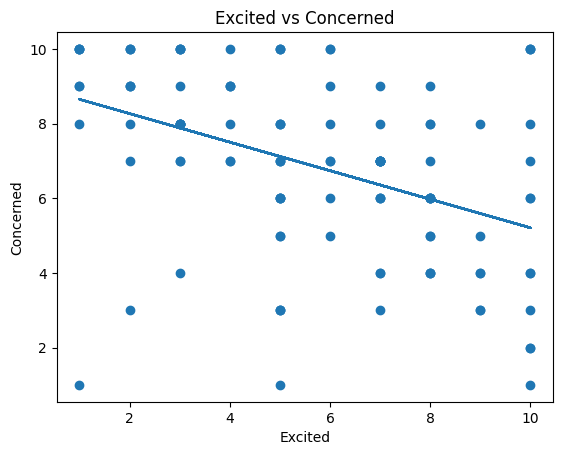

In [8]:
from scipy import stats

m, b, r, p, std_err = stats.linregress(x1, y1)
print(f"slope (m): {m:.3f}")
print(f"intercept (b): {b:.3f}")
print(f"Correlation coefficient (r): {r:.3f}")
print(f"Standard error: {std_err:.3f}")

x = np.array(df['Excited'])
y = np.array(df['Concerned'])
plt.xlabel('Excited')
plt.ylabel('Concerned')
plt.title('Excited vs Concerned')
plt.scatter(x, y)
y_hat  = m*x+b
plt.plot(x, y_hat)
plt.show()

In [13]:
df['EC_Delta'] = df['Excited'] - df['Concerned']

In [14]:
df

,ID,Start,End,Age,Gender,Excited,Why Excited,Concerned,Why Concerned,Use Freq,How Used,Tools,Comparison,EC_Delta
0,11,2/20/26 9:26:30,2/20/26 9:28:20,45-54,Male,4,Making coding easier,9,Concerned about impact on employment prospects...,Several times a day,"search, finding out how to code things.",Microsoft Copilot;Chat GPT;Google Gemini;,,-5
1,12,2/20/26 9:52:31,2/20/26 10:03:38,45-54,Female,8,It simplifies otherwise manual tasks and it’s ...,8,It has become a crutch for me - I have come to...,Several times a day,See above.,Chat GPT;Claude (Anthropic);Microsoft Copilot;,,0
2,13,2/20/26 11:52:56,2/20/26 11:54:14,55 or over,Female,7,NaN,4,NaN,A few times a week,Answer search questions,Chat GPT;Microsoft Copilot;,More Excited Than Concerned,3
3,14,2/20/26 11:55:10,2/20/26 12:06:45,25-34,Male,10,The possibilities that become more probable wh...,10,Dependency on AI to solve simple problems we s...,Several times a day,"Resume, Explain Complex Code, Math Tutor, draf...",Notebook LM;Google Gemini;Perplexity AI;Claude...,,0
4,15,2/20/26 13:38:13,2/20/26 13:39:51,45-54,Female,2,NaN,8,"Outsourced thinking, loss of human creativity ...",A few times a week,Analyse data.,Notebook LM;Chat GPT;Microsoft Copilot;,,-6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,119,3/4/26 10:13:23,3/4/26 10:15:23,25-34,Female,8,Being able to use AI as a tool to further my k...,4,The movie IRobot,Several times a day,"Spell check homework, answer questions",Google Gemini;Grammarly;Claude (Anthropic);Cha...,More Excited Than Concerned,4
109,120,3/4/26 11:00:36,3/4/26 11:18:28,25-34,Female,5,I feel neutral about the use of AI in people’s...,6,"Up until about 3 weeks ago, I did not think of...",A few times a week,I actually use it mainly for health reasons. I...,Chat GPT;Google Gemini;,,-1
110,121,3/4/26 11:19:28,3/4/26 11:23:29,45-54,Female,8,I can do work faster since i write many emails.,9,Water usage and young people using there brain...,About once a day,Help with items at work!,Chat GPT;Microsoft Copilot;Google Gemini;,,-1
111,122,3/4/26 11:24:48,3/4/26 11:29:46,35- 44,Female,8,I like to use AI for career development as wel...,6,I do worry about how it affects the environment.,Several times a day,"I use it for resume, cover letters, career pla...",Chat GPT;Perplexity AI;Google Gemini;,More Excited Than Concerned,2
